<p style="text-align:right;">Mario Stanke, University of Greifswald, Germany</p>

# Linear Regression Example <span style="font-size: small">(a very special case of a neural network)</span>

## Bike Sharing Demand
 - data set of *bike rental counts* in a Washington, D.C., bikeshare program 
 - much simplified data table with only
    - ```temp``` - temperature in Celsius
    - ```count``` - number of total rentals
    for individual hours during daytime and summer
    - other features like humidity, weekday, holiday and time of day ignored
 - **task**: predict bike rental demand (count of bikes) based on temperature
 - data source: [kaggle](https://www.kaggle.com/c/bike-sharing-demand)

Import libraries
 - [Pandas](https://pandas.pydata.org) for reading input tables from a file to a *data frame*.
 - [Matplotlib](https://matplotlib.org) for making plots.
 - [TensorFlow](https://www.tensorflow.org) to compute gradients and general machine learning.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torchsummary import summary
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
# load the training data from the table file to a pandas data frame
df = pd.read_csv("bikes-summerdays.tbl", sep = '\s+') # cols are split by at least one white space
df.head()

,temp,count
0,13.12,173
1,13.12,75
2,13.12,89
3,13.94,95
4,14.76,110


In [3]:
# convert count data from integer to float as regression target
df['count'] = df['count'].astype(float) 
df.dtypes

temp     float64
count    float64
dtype: object

The basic data structure of ML frameworks is the **Tensor** (or ndarray in numpy).
A tensor is a collection of numbers (in most cases with datatype float) with a specific **shape**.
The **shape** of a tensor is a tuple of numbers, where the length of the tuple is the number of **axes** or **rank** of the tensor and values are the **dimensions** or **depths** of the axes.

Our data is a 2-D (of rank 2 or with 2 axes) tensor with the following shape:

In [4]:
df.shape

(1482, 2)

(In fact, it's currently not a "tensor" per se, but a **pandas dataframe** that has not been converted to a numpy or tensorflow representation)

In [5]:
type(df)

pandas.core.frame.DataFrame

In [6]:
# assign training set size and number of columns to variable for later
m, n_cols = df.shape 

# compute average of hourly bike rental counts
meancount = np.mean(df['count'])
print ("mean bike count = ", meancount)

mean bike count =  311.0


### Make a first explorative plot

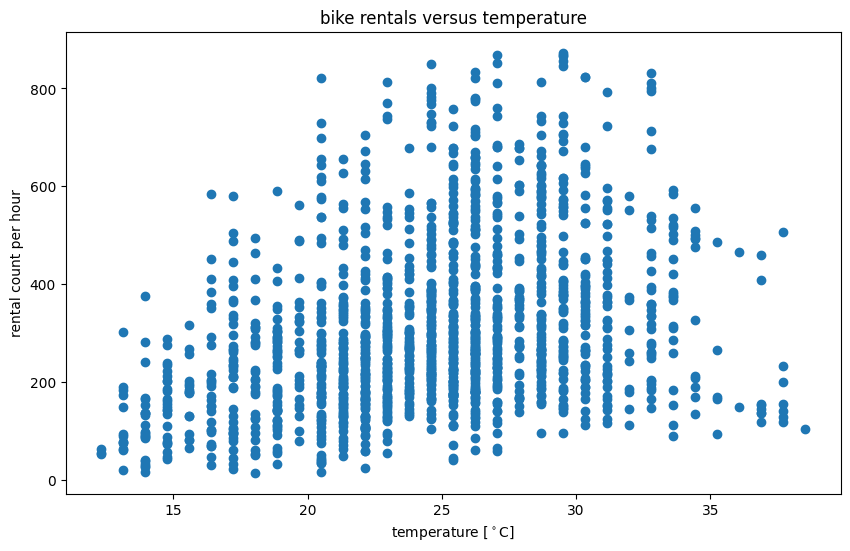

In [7]:
def scatterplot_rentals():
    ''' Plot the bike rental counts versus the temperature.'''
    _, ax = plt.subplots(figsize = (10, 6)) # width x height
    ax.scatter(df["temp"], df["count"])
    plt.title("bike rentals versus temperature")
    plt.xlabel('temperature [' + r'$^\circ$' + 'C]')
    plt.ylabel('rental count per hour');
    return ax

ax = scatterplot_rentals();

In [8]:
# print summary statistics 
df.describe()

,temp,count
count,1482.000000,1482.000000
mean,24.612173,311.000000
std,4.979788,174.792339
min,12.300000,14.000000
25%,21.320000,184.000000
50%,24.600000,272.000000
75%,27.880000,398.750000
max,38.540000,873.000000


## Define the loss function

In [9]:
# Mean squared error loss function that depends on the predictions.
def MSE(yhat):
    """
        Mean squared error function for linear regression
        yhat: The predictions, a vector of size m or a matrix with m rows
    """
    if yhat.dim() == 1:
        yhat = yhat.reshape(m, 1)
    if (type(y_train) == np.ndarray):
        y = torch.tensor(y_train, device=device)
    else:
        y = y_train
    if y.dim() < yhat.dim():
        y = y.reshape(m, 1)
    # now theta is a matrix in any case
    d = (yhat - y)**2 # square the residuals ('errors')
    E = torch.sum(d, dim=0) / m
    return E

## Baseline performance

Let's say we would have trained a model. How do we know we actually achieved something? We could look at the loss or some metric and see if it has decreased, but is that enough? 

Let's say you are given a trained model on a classification task that achieves $95\%$ accuracy (i.e. it is correct in $95\%$ of all cases). Can you say right away this is a good model?

No you can't (why?). 

We need a naive baseline to compare against. For a regression task, we can compute the error of a model, that always predicts the mean of the regression targets.

In [10]:
# stack the mean value in a (m,1) tensor
naive_yhat = np.repeat(meancount, m)
naive_yhat = torch.tensor(naive_yhat, device=device)

In [11]:
# extract response vector
y_train = np.array(df['count']) 

# check the loss of the baseline model
# also observe that the output is a tf.Tensor (because we used tf functions in MSE)
# This will be important later.
error = MSE(naive_yhat)
error

tensor([30531.7463], device='cuda:0', dtype=torch.float64)

## Linear Regression

Input variables $x_1,\ldots, x_n$ (<span style="color:red">features</span>). Here: $n=1$ and $x_1=$ temperature.

Real valued output variable $y$ (aka <span style="color:red">response</span> variable). Here, $y=$ bike count.

### Hypothesis function
Let ${\bf x}=(x_1,\ldots, x_n)$ be an input vector and 
$$\pmb{\theta} = \begin{pmatrix}\theta_0\\\vdots\\ \theta_n\end{pmatrix}$$

be a vector of unknown coefficients (<span style="color:red">parameters</span>). The function

$$h_{\pmb{\theta}}({\bf x}) := \theta_0 + \theta_1 x_1 + \cdots \theta_n x_n = (1, x_1, \cdots, x_n) \cdot \pmb{\theta}$$

is called the <span style="color:red">hypothesis</span>.

**Aim**: Find parameters $\pmb{\theta}$ such that, roughly speaking,
$h_{\pmb{\theta}}({\bf x}) \approx y$
for most *examples* $({\bf x}, y)$ from a data set or data distribution.

### Data set
Let $m$ be the number of training examples (pairs of input/output), 

$${\bf X} := \begin{pmatrix}
1 & x^{(1)}_1 & x^{(1)}_2 & \cdots & x^{(1)}_n\\
\vdots & \vdots & \vdots & &\vdots\\ 
1 & x^{(m)}_1 & x^{(m)}_2 & \cdots & x^{(m)}_n\\
\end{pmatrix} = \left(x^{(i)}_j\right)_{\tiny\begin{array}{l}1\le i\le m\\ 0\le j \le n\end{array}
},$$

be the *data matrix*, where $x^{(i)}_j$ is the value of the $j$-th feature of the $i$-th example, $x_0^{(j)}:=1$, and 

$${\bf y} = \begin{pmatrix}y_1\\\vdots\\y_m\end{pmatrix}$$

be the vector of responses.


### Mean squared error function
Define the *mean squared error* function

$$\text{MSE}(\pmb{\theta}) = \frac{1}{m} ({\bf X} \pmb{\theta} - {\bf y})^2  
= \frac{1}{m} \sum_{i=1}^m \left(h_{\pmb{\theta}}({\bf x}^{(i)}) - y_i\right)^2, \qquad \qquad (1)$$

where the square is meant to be applied componentwise to a vector. In machine learning (ML), $\text{MSE}$ is called a
<span style="color:red">loss function</span>. It is our target to be minimized:

$$ \text{MSE}(\pmb{\theta}) \to \min$$

## Create Data Matrix $X$ and response vector $y$

In [12]:
# extract feature columns
n = n_cols - 1 # number of features
temps = np.array(df.loc[:, df.columns != 'count']) # matrix of all other columns (here only one col)

# make data matrix X
X_train = np.ones((m, n+1)) # initialize with all ones
# overwrite all but the zero-th column with features

# normalize temperatures so they are roughly in [-1,1] 
X_train[:, 1:n+1] = temps / 10 - 2.5

X_train = torch.tensor(X_train, dtype=torch.float32, device=device)
y_train = torch.tensor(y_train, dtype=torch.float32, device=device)
y_train = y_train.reshape(m,1)
# print first 5 examples
print("X_train:\n ", X_train[0:5,], "\ny_train :" , y_train[0:5])

X_train:
  tensor([[ 1.0000, -1.1880],
        [ 1.0000, -1.1880],
        [ 1.0000, -1.1880],
        [ 1.0000, -1.1060],
        [ 1.0000, -1.0240]], device='cuda:0') 
y_train : tensor([[173.],
        [ 75.],
        [ 89.],
        [ 95.],
        [110.]], device='cuda:0')


## Implement the model

In [13]:
def linear_regression(X_train, theta):
    """
        Makes predictions on input data under a linear regression model with parameters theta.
        X_train: The data matrix
        theta: array of parameters, the first dimension must match the number of cols of X
               If theta is 2-dimensional, the output is 1-dim with one entry per col of theta.
    """
    if theta.dim() == 1: # theta is 1-dimensional
        theta = torch.reshape(theta, (-1, 1)) # make it a matrix with one column
    yhat = torch.matmul(X_train, theta) # vector of predicted rental counts
    return yhat

In [14]:
# this is for lecture purposes only
# your are not required to read it to understand the lesson
def contourPlot():
    ''' Plot the error landscape'''
    # compute error for the grid of all combinations of theta0 and theta1 values
    theta0 = theta1 = np.arange(-3200., 3200., 100) # grid axis ranges
    xv, yv = np.meshgrid(theta0, theta1) # x and y values of all grid points
    Theta = torch.tensor(np.array([xv, yv]).reshape(2, -1), dtype=torch.float32, device=device) # 2 rows, one col per grid point

    # compute error for all grid points
    z = MSE(linear_regression(X_train, Theta)).cpu().detach().numpy() # compute error grid
    z = z.reshape((theta0.size, -1)) # make this a matrix again as required by contour

    ## make contour plot
    _, axC = plt.subplots(figsize = (9, 8))
    # heights to draw contour lines for
    h = [50000, 200000] + list(range(500000, 6000001, 500000))
    contours = axC.contour(theta0, theta1, z, levels=h, colors='black')
    axC.clabel(contours, inline=True, fontsize=8, fmt='%i') # labels on lines
    plt.title("mean squared error " + r'$E(\theta)$');
    plt.xlabel(r'$\theta_0$')
    plt.ylabel(r'$\theta_1$');
    return axC

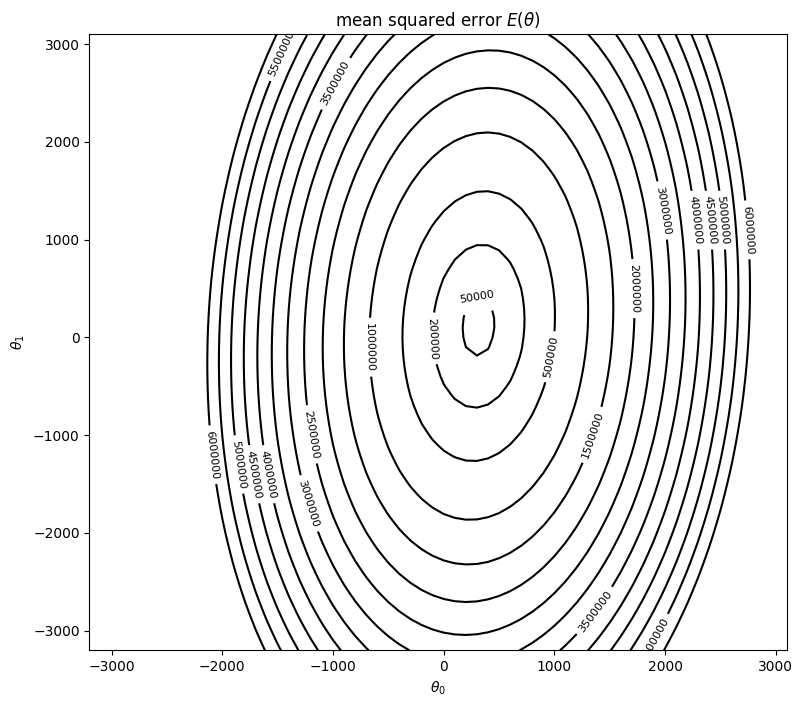

In [15]:
axC = contourPlot()

## Gradient and Gradient Descent
Gradient descent is a simple optimization algorithm, where the parameters are iteratively updated, by moving each time a (small) step into the direction of the steepest descend of the target function to be minimized:
$$ \pmb{\theta} \leftarrow \pmb{\theta} - \alpha \cdot\nabla \;\text{MSE}(\pmb{\theta})
\qquad \qquad \qquad (2)$$

Here, 
$$\nabla\; \text{MSE}(\pmb{\theta}) = \left(\frac{\partial\, \text{MSE}(\pmb{\theta})}{\partial\, \theta_0} , 
\ldots, \frac{\partial\, \text{MSE}(\pmb{\theta})}{\partial\, \theta_n}\right)^T$$ 
is the *gradient* of the mean squared error function in the point $\pmb{\theta}$ and $\alpha$ is called the *learning rate*. 

The rationale (not guaranteed) is that $\pmb{\theta}$ may converge to a *local* optimum. 
In applications other than linear regression a local optimum may not even be global.
In ML practice, usually a little more sophisticated methods are used, but they also require iterative updates based on the gradient.

*In order to compute the gradient we need a differentiable loss function. In modern Deep Learning, we **never** compute gradients by hand. We let TensorFlow automatically compute the gradients.*

*This requires that **all functions** used to compute the predictions ($\hat{y}$) and the loss are (differentiable) TensorFlow functions. Scroll up and check that this is indeed the case for our MSE and* `linear_regression` *implementations*

## Solution 1: low-level approach
Let us first (but never later) do it with a simple self-implemented gradient descent.

In [16]:
def gradient_descent(theta_init, learning_rate):
    ''' Simple gradient descent algorithm.'''
    N = 100  # number of update steps
    alpha = learning_rate
    
    # create variable for model parameters (weights) and initialize it
    theta = torch.tensor(theta_init, dtype=torch.float32, requires_grad=True, device=device)
    
    # variable to monitor progress
    err = np.zeros(N + 1)  # error after each update step
    Theta = np.zeros((2, N + 1))  # sequence of parameters after each step
    
    # simple gradient descent loop
    for i in range(N + 1):
        yhat = linear_regression(X_train, theta)
        E = MSE(yhat)
        
        Theta[:, i] = theta.cpu().detach().numpy()
        err[i] = E.squeeze()
        
        if i < N + 1:
            if theta.grad is not None:
                theta.grad.zero_()  # reset the gradient to zero
            E.backward()  # compute the derivative of E wrt to theta
            with torch.no_grad():
                theta -= alpha * theta.grad  # core update step from formula (2)
                theta.grad.zero_()  # reset the gradient to zero
            
            if i % 10 == 0:  # output some algorithm progress
                print("error after ", i, " iterations: ", err[i], " gradient= ", theta.grad.cpu().numpy())
    
    return [Theta, err]

## Visualization of optimization progress

In [17]:
def plot_error(err, col):
    ''' Plot error over time'''
    plt.subplots()
    plt.plot(np.log(err), 'o-', color=col, linewidth=.2, markersize=3, mfc='none')
    plt.title("Log error by iteration of gradient descent")
    plt.xlabel('iteration '+r'$i$')
    plt.ylabel(r'$ln \;E(\theta^{(i)})$');

def plot_progress(Theta, err, col, ):
    '''Plot error and parameters over time'''
    # enter parameter trajectory to above contour plot
    axC = contourPlot()
    plt.plot(Theta[0, 0], Theta[1, 0], 'o', color='green', mfc='none') # mark starting point with circle
    ymin, ymax = axC.get_ylim()
    xmin, xmax = axC.get_xlim()
    for i in range(1, Theta.shape[1]):
        if (np.abs(Theta[0, i] - Theta[0, i-1]) + np.abs(Theta[1, i] - Theta[1, i-1]) > 1e-6):
            # above condition avoids arrows with a length of 0 pixels
            plt.arrow(Theta[0, i-1], Theta[1, i-1], Theta[0, i] - Theta[0, i-1], Theta[1, i] - Theta[1, i-1],
                      color=col, width=3, head_length=20, head_width=50, overhang=.9, length_includes_head=True)
    plot_error(err, col)

### A <span style="color:darkgreen">successful</span> run of gradient descent

error after  0  iterations:  4562314.5  gradient=  [0. 0.]
error after  10  iterations:  182621.0625  gradient=  [0. 0.]
error after  20  iterations:  38312.4921875  gradient=  [0. 0.]
error after  30  iterations:  28014.9921875  gradient=  [0. 0.]
error after  40  iterations:  27280.177734375  gradient=  [0. 0.]
error after  50  iterations:  27227.7421875  gradient=  [0. 0.]
error after  60  iterations:  27224.0  gradient=  [0. 0.]
error after  70  iterations:  27223.734375  gradient=  [0. 0.]
error after  80  iterations:  27223.712890625  gradient=  [0. 0.]
error after  90  iterations:  27223.712890625  gradient=  [0. 0.]
error after  100  iterations:  27223.712890625  gradient=  [0. 0.]
theta after optimization:  [315.48110962 115.54233551]


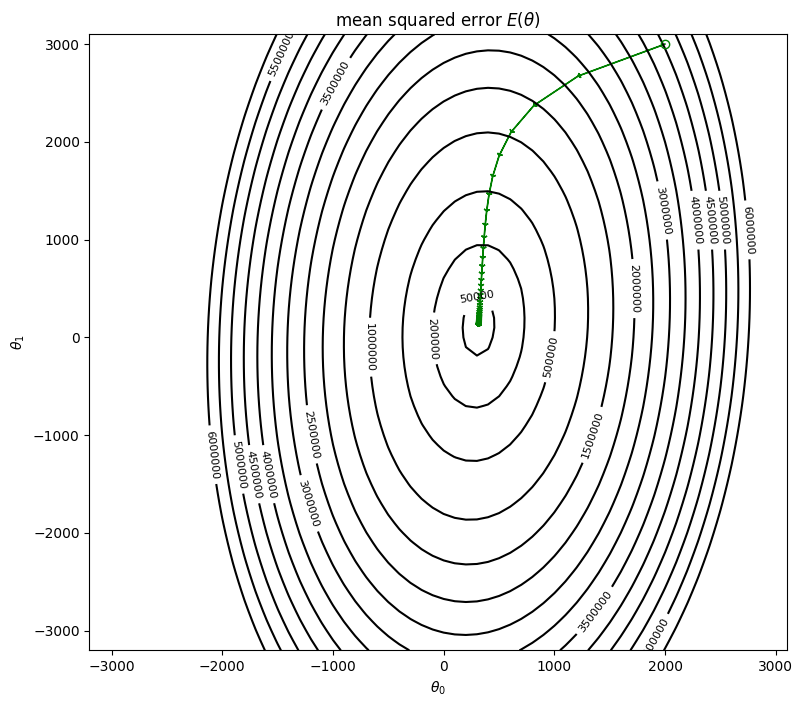

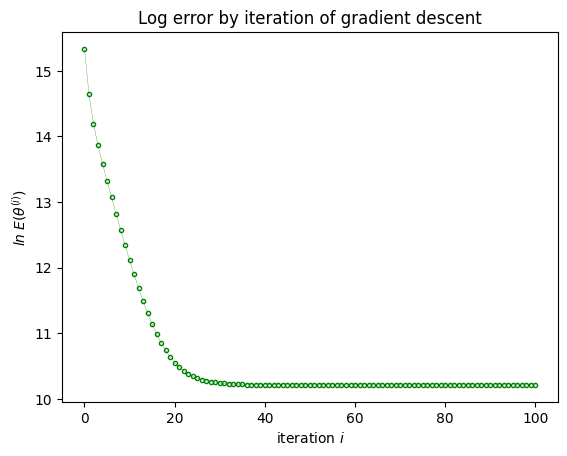

In [18]:
theta_init = np.array([2000., 3000.])
# a better starting value for theta would be [meancount, 0]

[Theta1, err1] = gradient_descent(theta_init, learning_rate = 0.25) 
print("theta after optimization: ", Theta1[:, -1])
plot_progress(Theta1, err1, col='green');

### An <span style="color:red">unsuccessful</span> run of gradient descent
If the learning rate is too high, a *local optimum* may not be found. 
If the learning rate is too small, learning can take a (prohibitively) long time.

error after  0  iterations:  4562314.5  gradient=  [0. 0.]
error after  10  iterations:  2580414.25  gradient=  [0. 0.]
error after  20  iterations:  2792426.5  gradient=  [0. 0.]
error after  30  iterations:  3022049.75  gradient=  [0. 0.]
error after  40  iterations:  3270741.5  gradient=  [0. 0.]
error after  50  iterations:  3540087.5  gradient=  [0. 0.]
error after  60  iterations:  3831798.25  gradient=  [0. 0.]
error after  70  iterations:  4147733.25  gradient=  [0. 0.]
error after  80  iterations:  4489904.0  gradient=  [0. 0.]
error after  90  iterations:  4860491.5  gradient=  [0. 0.]
error after  100  iterations:  5261849.5  gradient=  [0. 0.]
theta after optimization:  [ 2.59810059e+03 -2.07801819e+00]


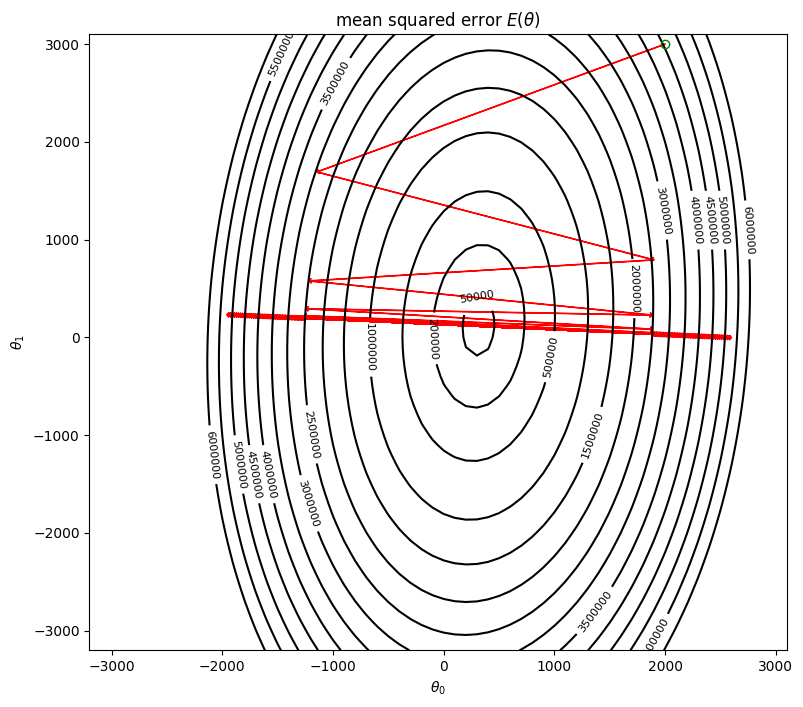

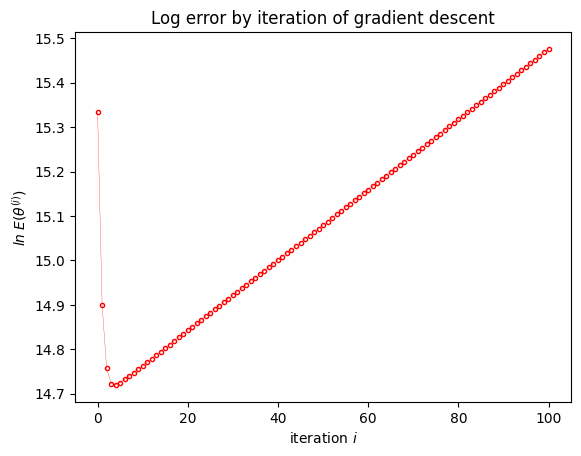

In [19]:
[Theta2, err2] = gradient_descent(theta_init, learning_rate = 1.0) # this learning rate is a little too high 
print("theta after optimization: ", Theta2[:, -1])
plot_progress(Theta2, err2, col='red');

## Solution 2: high-level approach
A high-level approach is recommended for most practical applications. For this, TensorFlow 2 uses a build-in Keras library with common ML functions and model components.

### Stochastic Gradient Descent
- Heuristics for minimizing some error or loss function $E(\pmb{\theta}; ({\bf X},{\bf y}))$ with respect to $\pmb{\theta}$ more efficiently than with regular gradient descent (Formula (2)), in particular for large training data sets $({\bf X},{\bf y})$.
- Also iteratively updates parameters $\pmb{\theta}$ on the basis of the gradient $\nabla E$, but the gradient is computed only for a (small) sample $(Xbatch, Ybatch)$ of the training data. The number of examples in the batch are called the **batch size**.
- The **learning rate** $\alpha$ plays a similar role as in regular gradient descent: The larger $\alpha$, the larger the changes to $\pmb{\theta}$ in each step.
- $0\le \mu \le 1$ is called **momentum**. If $\mu = 0$, the update step is like in regular gradient descent, except that the gradient is computed on a batch only. With increasing $\mu$ the update steps are larger and fluctuate less.
 > ${\bf v} \leftarrow {\bf 0}$  
 > While the termination condition is not satisfied
 >> Sample a random batch $(\text{Xbatch},\text{Ybatch})$ from the training data $({\bf X},{\bf y})$.  
 >> ${\bf v} \leftarrow \mu \cdot {\bf v} - \alpha \cdot \nabla E(\pmb{\theta};\text{Xbatch},\text{Ybatch}))$  
 >> $\pmb{\theta} \leftarrow \pmb{\theta} + {\bf v}$ 
  
- The termination condition could be
   1. A fixed number of iterations has been done.
   2. The accuracy/error on a separate validation set satisfies some condition (e.g. it is plateauing).
   3. User interruption.
- Often, the random choices of batches are such that the number of times each example appeared in a batch differs at most by 1, i.e. the batch is drawn from the subset of examples used hitherto one less than the maximum. Once all examples have been used once, an **epoch** ends.
- Documentation and Code of [torch.optim.SGD](https://pytorch.org/docs/stable/generated/torch.optim.SGD.html)
  

In [20]:
y_train

tensor([[173.],
        [ 75.],
        [ 89.],
        ...,
        [514.],
        [458.],
        [276.]], device='cuda:0')

In [21]:
# Create a DataLoader (PyTorch equivalent of tf.data.Dataset)
batch_size = 32
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Print one batch to verify
x_batch, y_batch = next(iter(train_loader))
print("x_batch shape:", x_batch.shape)
print(x_batch)
print("y_batch shape:", y_batch.shape)
print(y_batch)

x_batch shape: torch.Size([32, 2])
tensor([[ 1.0000, -0.4500],
        [ 1.0000, -0.7780],
        [ 1.0000,  0.6160],
        [ 1.0000,  0.1240],
        [ 1.0000,  0.3700],
        [ 1.0000, -0.0400],
        [ 1.0000, -0.1220],
        [ 1.0000,  1.1900],
        [ 1.0000, -0.6140],
        [ 1.0000,  1.2720],
        [ 1.0000, -0.0400],
        [ 1.0000, -0.0400],
        [ 1.0000,  0.6160],
        [ 1.0000,  0.0420],
        [ 1.0000,  0.1240],
        [ 1.0000,  0.7800],
        [ 1.0000,  1.0260],
        [ 1.0000,  0.1240],
        [ 1.0000,  0.4520],
        [ 1.0000,  0.3700],
        [ 1.0000, -0.3680],
        [ 1.0000,  0.0420],
        [ 1.0000,  0.6160],
        [ 1.0000, -0.4500],
        [ 1.0000,  0.6160],
        [ 1.0000,  0.3700],
        [ 1.0000,  0.0420],
        [ 1.0000, -0.5320],
        [ 1.0000, -0.0400],
        [ 1.0000, -0.1220],
        [ 1.0000,  0.5340],
        [ 1.0000,  0.4520]], device='cuda:0')
y_batch shape: torch.Size([32, 1])
tensor([[107.],


In [22]:
# Define the model (linear regression with a single output, no bias)
# Note: torch.nn.Linear expects weight shape as (out_features, in_features)
model = nn.Sequential(nn.Linear(in_features=2, out_features=1, bias=False))
# Move model to device
model = model.to(device)

In [23]:
# Initialize model weights with theta_init
theta_init = np.array([2000., 3000.]).reshape((1, 2))  # shape (1,2) to match torch.nn.Linear
with torch.no_grad():
    model[0].weight.copy_(torch.tensor(theta_init, dtype=torch.float32, device=device))


In [24]:
# Define loss function and optimizer
loss_fn = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.8)

# Print model info
print(model)
summary(model, input_size=(batch_size, 2), device=str(device))
print (model[0].weight)

Sequential(
  (0): Linear(in_features=2, out_features=1, bias=False)
)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                [-1, 32, 1]               2
Total params: 2
Trainable params: 2
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------
Parameter containing:
tensor([[2000., 3000.]], device='cuda:0', requires_grad=True)


In [25]:
# Optional: set up lists to record training progress (theta and loss)
theta_history = []
loss_history = []
X_train = X_train.to(device)
y_train = y_train.to(device)
# Train the model for 5 epochs (each epoch: one pass over the dataset)
epochs = 5
for epoch in range(epochs):
    running_loss = 0.0
    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        optimizer.zero_grad()            # reset gradients
        predictions = model(batch_x)       # forward pass
        loss = loss_fn(predictions, batch_y)  # compute loss
        loss.backward()                    # compute gradients
        optimizer.step()                   # update parameters
        running_loss += loss.item()
        
    avg_loss = running_loss / len(train_loader)
    loss_history.append(avg_loss)
    theta_history.append(model[0].weight.detach().clone())
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss}")


Epoch 1/5, Loss: 1349354.074468085
Epoch 2/5, Loss: 101094.19822140958
Epoch 3/5, Loss: 32856.953769115695
Epoch 4/5, Loss: 27373.199343417553
Epoch 5/5, Loss: 27557.95162898936


Final loss on training data: 27374.921875
Final theta (weights):
 [[327.80753 118.29714]]


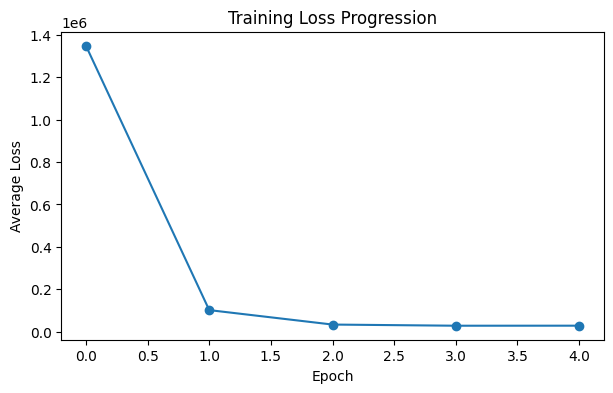

In [26]:

# Final predictions on the entire training set
with torch.no_grad():
    pred = model(X_train)
final_loss = loss_fn(pred, y_train).item()
print("Final loss on training data:", final_loss)
print("Final theta (weights):\n", model[0].weight.cpu().detach().numpy())

# (Optional) Plot loss progression over epochs
plt.figure(figsize=(7,4))
plt.plot(loss_history, 'o-')
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.title('Training Loss Progression')
plt.show()

**Remarks:**
  - In above plot of training error, the errors were measured only on a batch and are thus estimates of the training error only.
  - When using stochastic gradient descent, typically the parameter trajectory eventually random walks near a local optimum and their latest values may result in a larger loss than some parameter value previously attained.

In [27]:
# lets compare it to our baseline error:
MSE(naive_yhat).cpu().numpy()[0]

30531.74628879892

We can see that depending on the initial parameters, we can start gradient descent a much higher error values than the baseline. So a decrease compared to the starting point of training is not enough to tell us we achieved something.

## Plot predictions

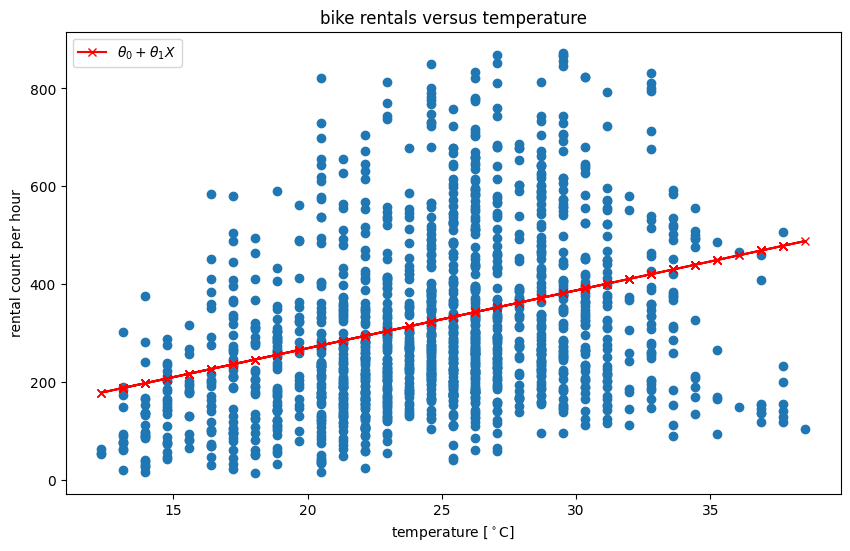

In [28]:
# draw the same scatterplot as above
ax = scatterplot_rentals()

# now add the predictions, here a regression line
ax.plot(temps, pred.cpu().numpy(), 'rx-', label = r"$\theta_0 + \theta_1 X$") # - draws line connecting (r)ed crosses (x)
ax.legend(loc = 'upper left');